# Customer Churn Prediction

Predicting which telecom customers are likely to churn using the public
[Telco Customer Churn dataset](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)
(7,043 customer records, IBM sample dataset via Kaggle).

Three models are compared — Logistic Regression, k-Nearest Neighbors, and a
Neural Network (MLPClassifier) — and the results are translated into
business recommendations for reducing churn.


In [1]:
import pandas as pd

df = pd.read_csv("Telco_Customer_Churn.csv")
print(df.head())
print("\nShape of dataset:", df.shape)
print("\nDataset Info:")
print(df.info())


   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

## Data Cleaning

In [2]:
# Drop the ID column (not predictive), and clean up TotalCharges
df.drop("customerID", axis=1, inplace=True)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Missing TotalCharges:", df["TotalCharges"].isna().sum())

df.dropna(subset=["TotalCharges"], inplace=True)
df.reset_index(drop=True, inplace=True)

print("\nUpdated Info:")
print(df.info())


Missing TotalCharges: 11

Updated Info:
<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   str    
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   str    
 3   Dependents        7032 non-null   str    
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   str    
 6   MultipleLines     7032 non-null   str    
 7   InternetService   7032 non-null   str    
 8   OnlineSecurity    7032 non-null   str    
 9   OnlineBackup      7032 non-null   str    
 10  DeviceProtection  7032 non-null   str    
 11  TechSupport       7032 non-null   str    
 12  StreamingTV       7032 non-null   str    
 13  StreamingMovies   7032 non-null   str    
 14  Contract          7032 non-null   str    
 15  PaperlessBilling  7032 non-null   str    
 16  PaymentMethod

## Exploratory Visualizations

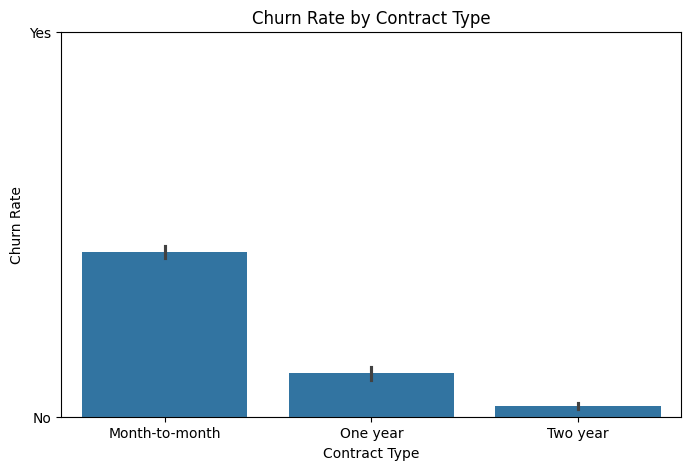

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Contract", y="Churn", estimator=lambda x: sum(x) / len(x))
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate")
plt.xlabel("Contract Type")
plt.ylim(0, 1)
plt.grid(True, axis="y")
plt.show()


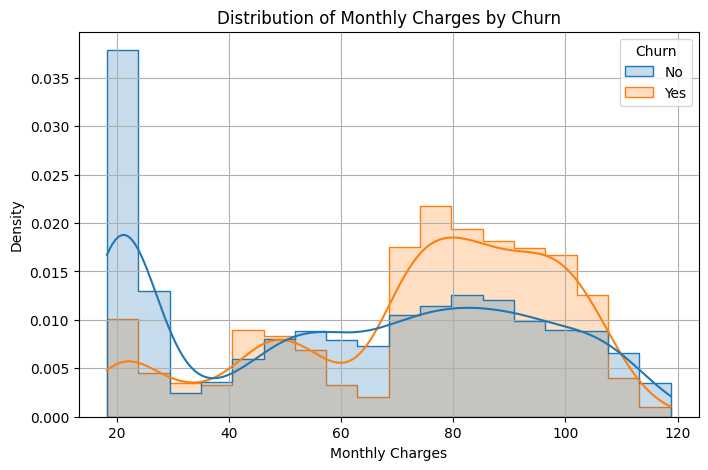

In [4]:
plt.figure(figsize=(8, 5))
sns.histplot(
    data=df, x="MonthlyCharges", hue="Churn", kde=True,
    element="step", stat="density", common_norm=False
)
plt.title("Distribution of Monthly Charges by Churn")
plt.xlabel("Monthly Charges")
plt.ylabel("Density")
plt.grid(True)
plt.show()


## Encoding Categorical Variables

In [5]:
# Convert target variable to binary, one-hot encode the rest
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})
df_encoded = pd.get_dummies(df, drop_first=True)

print("Shape after encoding:", df_encoded.shape)
print("\nEncoded columns:\n", df_encoded.columns.tolist())


Shape after encoding: (7032, 31)

Encoded columns:
 ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [6]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Training set shape: (5625, 30)
Test set shape: (1407, 30)


## Feature Engineering

In [7]:
import numpy as np

# Average monthly spend (guard against divide-by-zero for brand-new customers)
df["AvgMonthlySpend"] = df.apply(
    lambda row: row["TotalCharges"] / row["tenure"] if row["tenure"] > 0 else 0,
    axis=1,
)

# Bucket tenure into groups to capture behavior-over-time effects
bins = [0, 12, 24, 48, 60, np.inf]
labels = ["0-12 mo", "13-24 mo", "25-48 mo", "49-60 mo", "60+ mo"]
df["TenureGroup"] = pd.cut(df["tenure"], bins=bins, labels=labels, right=False)

print(df[["tenure", "AvgMonthlySpend", "TenureGroup"]].head())

df = pd.get_dummies(df, columns=["TenureGroup"], drop_first=True)
df = pd.get_dummies(df, drop_first=True)

X = df.drop("Churn", axis=1)
y = df["Churn"]


   tenure  AvgMonthlySpend TenureGroup
0       1        29.850000     0-12 mo
1      34        55.573529    25-48 mo
2       2        54.075000     0-12 mo
3      45        40.905556    25-48 mo
4       2        75.825000     0-12 mo


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

correlations = (
    df.corr(numeric_only=True)["Churn"].drop("Churn").sort_values(ascending=False)
)
print("Top positive correlations with Churn:\n", correlations.head(10))
print("\nTop negative correlations with Churn:\n", correlations.tail(10))


Top positive correlations with Churn:
 InternetService_Fiber optic       0.307463
PaymentMethod_Electronic check    0.301455
MonthlyCharges                    0.192858
AvgMonthlySpend                   0.192033
PaperlessBilling_Yes              0.191454
SeniorCitizen                     0.150541
StreamingTV_Yes                   0.063254
StreamingMovies_Yes               0.060860
MultipleLines_Yes                 0.040033
TenureGroup_13-24 mo              0.027783
Name: Churn, dtype: float64

Top negative correlations with Churn:
 StreamingTV_No internet service        -0.227578
InternetService_No                     -0.227578
StreamingMovies_No internet service    -0.227578
OnlineSecurity_No internet service     -0.227578
OnlineBackup_No internet service       -0.227578
DeviceProtection_No internet service   -0.227578
TechSupport_No internet service        -0.227578
TenureGroup_60+ mo                     -0.232917
Contract_Two year                      -0.301552
tenure                

Tenure, contract type, monthly charges, and payment method stood out as the
strongest churn drivers — customers on month-to-month contracts, with short
tenure, or paying by electronic check churned at noticeably higher rates.

## Model 1 — Logistic Regression

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Results:")
print("Accuracy:", round(accuracy_score(y_test, y_pred_log), 4))
print("Precision:", round(precision_score(y_test, y_pred_log), 4))
print("Recall:", round(recall_score(y_test, y_pred_log), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_log), 4))
print("ROC AUC:", round(roc_auc_score(y_test, y_prob_log), 4))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))

# Best for interpretability and as a baseline model.
# Strength: strong AUC and accuracy for a linear model.
# Weakness: may underperform on recall or non-linear patterns.


Logistic Regression Results:
Accuracy: 0.7918
Precision: 0.6302
Recall: 0.5241
F1 Score: 0.5723
ROC AUC: 0.8347

Confusion Matrix:
 [[918 115]
 [178 196]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Model 2 — k-Nearest Neighbors

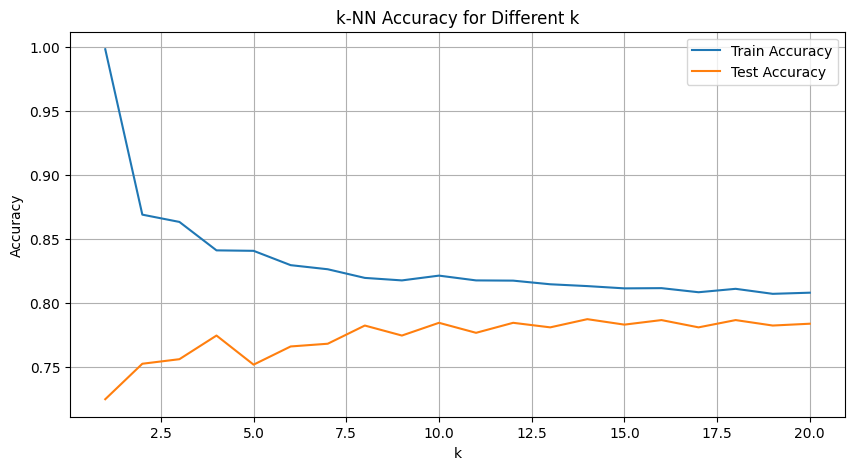

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

k_range = range(1, 21)
train_accuracies, test_accuracies = [], []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    train_accuracies.append(accuracy_score(y_train, knn.predict(X_train_scaled)))
    test_accuracies.append(accuracy_score(y_test, knn.predict(X_test_scaled)))

plt.figure(figsize=(10, 5))
plt.plot(k_range, train_accuracies, label="Train Accuracy")
plt.plot(k_range, test_accuracies, label="Test Accuracy")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("k-NN Accuracy for Different k")
plt.legend()
plt.grid(True)
plt.show()


In [11]:
best_k = 20
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)

y_pred_knn = knn_final.predict(X_test_scaled)
y_prob_knn = knn_final.predict_proba(X_test_scaled)[:, 1]

print(f"k-NN Results (k={best_k}):")
print("Accuracy:", round(accuracy_score(y_test, y_pred_knn), 4))
print("Precision:", round(precision_score(y_test, y_pred_knn), 4))
print("Recall:", round(recall_score(y_test, y_pred_knn), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_knn), 4))
print("ROC AUC:", round(roc_auc_score(y_test, y_prob_knn), 4))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))

# Best for capturing local, non-linear patterns.
# Strength: simple, non-parametric, solid ROC AUC.
# Weakness: slightly lower recall and F1 than logistic regression.


k-NN Results (k=20):
Accuracy: 0.7839
Precision: 0.6067
Recall: 0.5321
F1 Score: 0.567
ROC AUC: 0.8199

Confusion Matrix:
 [[904 129]
 [175 199]]


## Model 3 — Neural Network (MLPClassifier)

In [12]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    "hidden_layer_sizes": [(8,), (16,), (8, 8), (16, 8)],
    "activation": ["relu", "tanh"],
    "learning_rate_init": [0.001, 0.0001],
    "max_iter": [100],
    "batch_size": [32, 64],
}

mlp = MLPClassifier(random_state=42)
grid_search = GridSearchCV(mlp, param_grid, cv=3, scoring="f1", n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train)


Fitting 3 folds for each of 32 candidates, totalling 96 fits


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


...

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MLPClassifier(random_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'activation': ['relu', 'tanh'], 'batch_size': [32, 64], 'hidden_layer_sizes': [(8,), (16,), ...], 'learning_rate_init': [0.001, 0.0001], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each

In [13]:
best_mlp = grid_search.best_estimator_
print("Best parameters found:", grid_search.best_params_)

y_pred_mlp = best_mlp.predict(X_test_scaled)
y_prob_mlp = best_mlp.predict_proba(X_test_scaled)[:, 1]

print("Neural Network Results:")
print("Accuracy:", round(accuracy_score(y_test, y_pred_mlp), 4))
print("Precision:", round(precision_score(y_test, y_pred_mlp), 4))
print("Recall:", round(recall_score(y_test, y_pred_mlp), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_mlp), 4))
print("ROC AUC:", round(roc_auc_score(y_test, y_prob_mlp), 4))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_mlp))

# Best for capturing non-linear interactions between features.
# Strength: flexible, competitive AUC.
# Weakness: slightly lower F1 than logistic regression; longer to train and tune.


Best parameters found: {'activation': 'relu', 'batch_size': 32, 'hidden_layer_sizes': (8, 8), 'learning_rate_init': 0.0001, 'max_iter': 100}
Neural Network Results:
Accuracy: 0.7925
Precision: 0.6178
Recall: 0.5749
F1 Score: 0.5956
ROC AUC: 0.8296

Confusion Matrix:
 [[900 133]
 [159 215]]


## Business Insights & Recommendations

**Key churn drivers**
- **Tenure** — shorter-tenure customers churn at much higher rates.
- **Contract type** — month-to-month contracts are strongly linked to churn.
- **Monthly charges / average spend** — higher spending correlates with higher churn.
- **Payment method** — electronic-check payers churn more than other methods.
- **Fiber optic internet** — this segment shows elevated churn, possibly pointing to service dissatisfaction.

**Recommendations**
1. Incentivize longer contracts (1–2 years) with loyalty discounts.
2. Use the model to flag high-risk customers for proactive retention outreach.
3. Bundle services for high-spending customers to increase perceived value.
4. Prioritize onboarding and support quality for new and fiber-optic customers.

**Deployment note:** the model could be integrated into a CRM to automatically
flag at-risk customers, letting retention teams act before customers churn.
Predictions should be refreshed regularly, since churn drivers can shift the
model doesn't capture qualitative signals like support tickets or satisfaction
survey scores.

Logistic regression offered the best balance of performance and
interpretability among the three models, which matters for explaining
churn drivers to a non-technical business audience.
